# `groundinsight` — pandapower import walkthrough

Quick, end-to-end demonstration of the pandapower importer added in
`groundinsight.io.pandapower_import`:

1. Build a small pandapower MV network with one out-of-service branch and
   a low-voltage stub (so we can exercise the voltage-level filter).
2. Inspect the planned mapping with `preview_pandapower_import`.
3. Convert the network with `from_pandapower`.
4. Add a project-specific source and fault, solve.
5. Run an outage study on top of the imported network.

**Prerequisite.** The pandapower extra:

```
pip install 'groundinsight[pandapower]'
# or
poetry install --extras pandapower
```


In [1]:
import sys
import os

# Make the src/ tree importable when running from the notebooks/ folder
project_root = os.path.abspath(os.path.join(os.getcwd(), '..', 'src'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import polars as pl
import matplotlib.pyplot as plt

import pandapower as pp
import groundinsight as gi
from groundinsight.models.core_models import BusType, BranchType

print('groundinsight', gi.__version__)
print('pandapower  ', pp.__version__)


groundinsight 0.3.2
pandapower   3.1.2


## 1. Build a small pandapower network

Five MV buses (20 kV) in a line, plus one LV stub bus (0.4 kV) connected
through a non-physical line so we can exercise the voltage-level filter.
One MV branch is set to `in_service=False` to demonstrate that the flag
propagates to `Branch.active = False` on the groundinsight side.


In [2]:
net = pp.create_empty_network(name='ms_demo')

# 20 kV main feeder
b1 = pp.create_bus(net, vn_kv=20.0, name='bus_mv_1')
b2 = pp.create_bus(net, vn_kv=20.0, name='bus_mv_2')
b3 = pp.create_bus(net, vn_kv=20.0, name='bus_mv_3')
b4 = pp.create_bus(net, vn_kv=20.0, name='bus_mv_4')
b5 = pp.create_bus(net, vn_kv=20.0, name='bus_mv_5')

# 0.4 kV stub -- different voltage level, must be filtered out
b_lv = pp.create_bus(net, vn_kv=0.4, name='bus_lv_1')

# Cable parameters representative of a 20 kV XLPE run; the exact values
# do not matter for the demo because the importer overrides them with
# the BranchType supplied via ImportDefaults.
common_kwargs = dict(
    r_ohm_per_km=0.25,
    x_ohm_per_km=0.6,
    c_nf_per_km=0.0,
    max_i_ka=0.4,
)

pp.create_line_from_parameters(net, from_bus=b1, to_bus=b2, length_km=1.5,
                                name='line_mv_12', **common_kwargs)
pp.create_line_from_parameters(net, from_bus=b2, to_bus=b3, length_km=2.0,
                                name='line_mv_23', **common_kwargs)
# Marked as out-of-service to demonstrate active-flag propagation.
pp.create_line_from_parameters(net, from_bus=b3, to_bus=b4, length_km=1.2,
                                name='line_mv_34_oos', in_service=False,
                                **common_kwargs)
pp.create_line_from_parameters(net, from_bus=b4, to_bus=b5, length_km=1.8,
                                name='line_mv_45', **common_kwargs)
# Cross-voltage-level branch: pure filter-test stub.
pp.create_line_from_parameters(net, from_bus=b5, to_bus=b_lv, length_km=0.05,
                                name='line_mv_to_lv_stub', **common_kwargs)

print(f'{len(net.bus)} buses, {len(net.line)} lines')


6 buses, 5 lines


## 2. Preview the import

`preview_pandapower_import` is a pure inspection: it does not build a
groundinsight `Network`. The returned DataFrame lists every pp bus and
line with `status='keep'` or `status='skip'` plus a `reason` so we can
confirm the mapping before committing to it.


In [3]:
preview = gi.preview_pandapower_import(net, voltage_level_kV=20.0)
preview.sort('kind', 'status', 'pp_index')


kind,status,pp_index,name,vn_kv,from_bus,to_bus,length_km,in_service,reason
str,str,i64,str,f64,str,str,f64,bool,str
"""bus""","""keep""",0,"""bus_mv_1""",20.0,null,null,null,true,null
"""bus""","""keep""",1,"""bus_mv_2""",20.0,null,null,null,true,null
"""bus""","""keep""",2,"""bus_mv_3""",20.0,null,null,null,true,null
"""bus""","""keep""",3,"""bus_mv_4""",20.0,null,null,null,true,null
"""bus""","""keep""",4,"""bus_mv_5""",20.0,null,null,null,true,null
…,…,…,…,…,…,…,…,…,…
"""line""","""keep""",0,"""line_mv_12""",null,"""bus_mv_1""","""bus_mv_2""",1.5,true,null
"""line""","""keep""",1,"""line_mv_23""",null,"""bus_mv_2""","""bus_mv_3""",2.0,true,null
"""line""","""keep""",2,"""line_mv_34_oos""",null,"""bus_mv_3""","""bus_mv_4""",1.2,false,null


**Expected.** Five 20 kV buses kept (one of them with
`in_service=False` propagated to `active=False` after the actual
import), the LV stub bus skipped with reason
`voltage_level_mismatch`, four MV-MV lines kept, and the MV→LV stub
line skipped with reason `endpoint_off_target_voltage_level`.


## 3. Convert with `from_pandapower`

Project-level defaults travel via `ImportDefaults`. The importer applies
`default_bus_type` to every imported bus and `default_branch_type` to
every imported line; soil resistivity `rho` and the frequency list are
the same for the whole import.


In [4]:
bus_type = BusType(
    name='ImportedBus',
    description='Default bus type for the demo import',
    system_type='Grounded',
    voltage_level=20.0,
    impedance_formula='rho * 0 + 1.0 + I * f * 0',
)

branch_type = BranchType(
    name='ImportedCable',
    description='MV cable (R=0.25 ohm/km, omega*L=0.6 ohm/km at 50 Hz)',
    grounding_conductor=True,
    self_impedance_formula='(0.25 + I * 0.6) * l',
    mutual_impedance_formula='(0.0 + I * 0.6) * l',
)

defaults = gi.ImportDefaults(
    rho=100.0,
    frequencies=[50.0],
    default_bus_type=bus_type,
    default_branch_type=branch_type,
)

network = gi.from_pandapower(net, defaults=defaults, voltage_level_kV=20.0,
                              network_name='ms_demo_groundinsight')

print(f'imported {len(network.buses)} buses, {len(network.branches)} branches')
print()
print('active flags:')
for name, bus in network.buses.items():
    print(f'  bus    {name:<12} active={bus.active}')
for name, branch in network.branches.items():
    print(f'  branch {name:<22} active={branch.active}  '
          f'length={branch.length:.2f} km')


imported 5 buses, 4 branches

active flags:
  bus    bus_mv_1     active=True
  bus    bus_mv_2     active=True
  bus    bus_mv_3     active=True
  bus    bus_mv_4     active=True
  bus    bus_mv_5     active=True
  branch line_mv_12             active=True  length=1.50 km
  branch line_mv_23             active=True  length=2.00 km
  branch line_mv_34_oos         active=False  length=1.20 km
  branch line_mv_45             active=True  length=1.80 km


## 4. Add a fault and solve

The importer never invents sources or fault locations — those are
project-specific. Here we inject 1 kA at `bus_mv_1` and place a
single-phase fault at `bus_mv_5`. The previously out-of-service
`line_mv_34_oos` would interrupt the path, so we re-activate it for
this baseline solve. The next section restores it to its original
disabled state for the outage study.


In [5]:
# Re-activate the OOS branch so the baseline solve has a closed path
network.branches['line_mv_34_oos'].active = True

gi.create_source(name='src', bus='bus_mv_1', values={50: 1000.0}, network=network)
gi.create_fault(name='F1', bus='bus_mv_5', scalings={50: 1.0}, network=network)

gi.run_fault(network, fault_name='F1', auto_parallel_coefficients=True)

network.res_buses(fault='F1').filter(pl.col('frequency_Hz') == 'RMS')


bus_name,fault,frequency_Hz,EPR_V,EPR_degree,I_bus_A,I_bus_degree
str,str,str,f64,f64,f64,f64
"""bus_mv_1""","""F1""","""RMS""",260.202678,null,260.202678,null
"""bus_mv_2""","""F1""","""RMS""",110.040348,null,110.040348,null
"""bus_mv_3""","""F1""","""RMS""",11.92197,null,11.92197,null
"""bus_mv_4""","""F1""","""RMS""",90.229852,null,90.229852,null
"""bus_mv_5""","""F1""","""RMS""",270.595801,null,270.595801,null


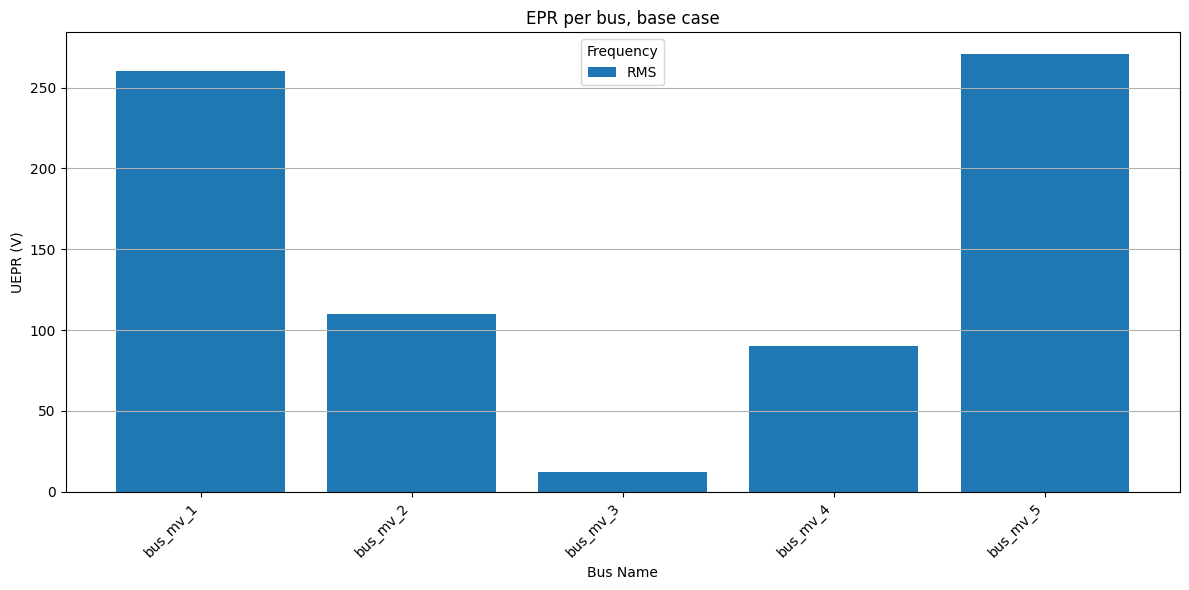

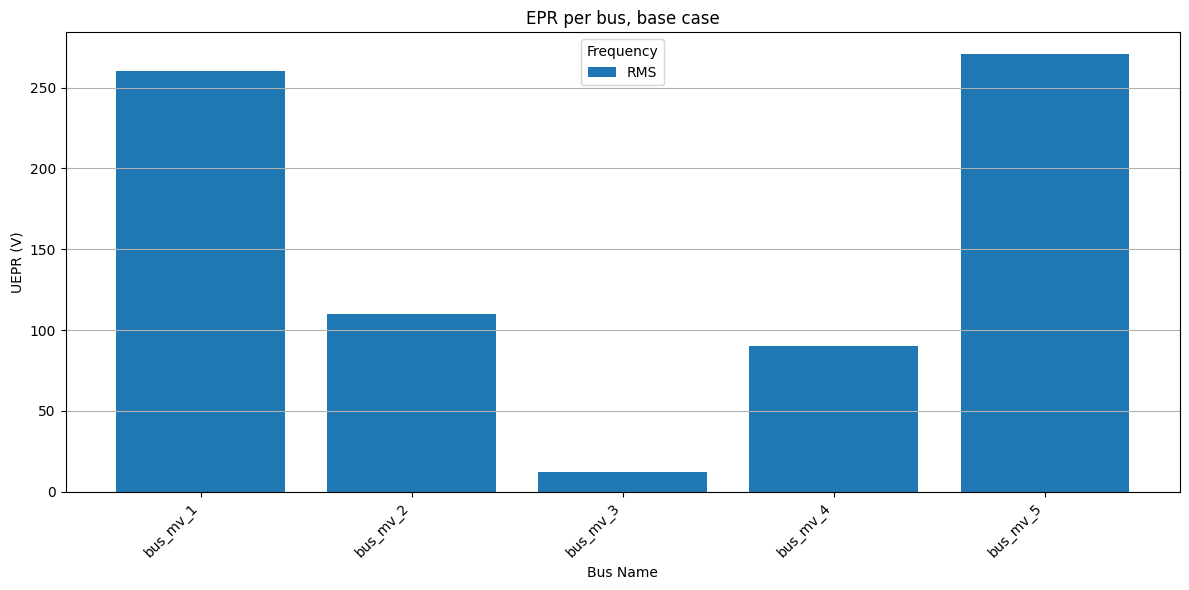

In [6]:
result = network.results['F1']
gi.plot_bus_voltages(result, title='EPR per bus, base case', show=True)


## 5. Outage study on the imported network

Combine the new importer (UC 2) with the outage layer (UC 3): take the
imported network as-is and compare two what-if scenarios against the
base case in a single call.

The `OutageStudyResult.compare_buses` helper returns a long-format
DataFrame with absolute and relative deltas against the chosen
reference scenario (base case by default).


In [7]:
study = gi.run_outage_study(
    network,
    fault='F1',
    scenarios=[
        gi.Outage(
            name='line_mv_23_open',
            disabled_branches=['line_mv_23'],
            description='Cable section 2-3 cut out for maintenance',
        ),
        gi.Outage(
            name='bus3_isolated',
            disabled_buses=['bus_mv_3'],
            description='Substation 3 fully disconnected',
        ),
    ],
    auto_parallel_coefficients=True,
)

# RMS EPR per bus per scenario, with absolute and relative delta vs base
study.compare_buses().filter(pl.col('frequency_Hz') == 'RMS')


bus_name,frequency_Hz,metric,value,scenario,delta_vs_base,delta_pct_vs_base
str,str,str,f64,str,f64,f64
"""bus_mv_1""","""RMS""","""EPR_V""",260.202678,"""base""",0.0,0.0
"""bus_mv_2""","""RMS""","""EPR_V""",110.040348,"""base""",0.0,0.0
"""bus_mv_3""","""RMS""","""EPR_V""",11.92197,"""base""",0.0,0.0
"""bus_mv_4""","""RMS""","""EPR_V""",90.229852,"""base""",0.0,0.0
"""bus_mv_5""","""RMS""","""EPR_V""",270.595801,"""base""",0.0,0.0
…,…,…,…,…,…,…
"""bus_mv_5""","""RMS""","""EPR_V""",0.0,"""line_mv_23_open""",-270.595801,-100.0
"""bus_mv_1""","""RMS""","""EPR_V""",0.0,"""bus3_isolated""",-260.202678,-100.0
"""bus_mv_2""","""RMS""","""EPR_V""",0.0,"""bus3_isolated""",-110.040348,-100.0


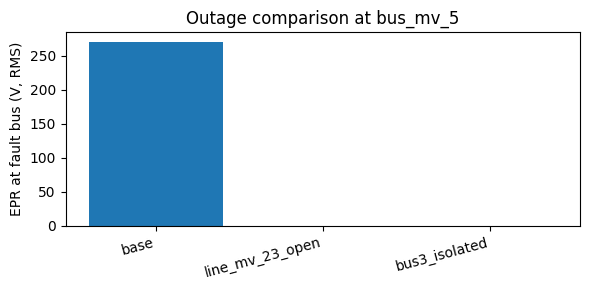

In [8]:
# Quick visual: side-by-side bar plot of EPR at the fault bus
df = (
    study.compare_buses()
    .filter((pl.col('frequency_Hz') == 'RMS') & (pl.col('bus_name') == 'bus_mv_5'))
    .select(['scenario', 'value'])
)
labels = df['scenario'].to_list()
values = df['value'].to_list()

fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(labels, values)
ax.set_ylabel('EPR at fault bus (V, RMS)')
ax.set_title('Outage comparison at bus_mv_5')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()


## Summary

- `preview_pandapower_import` validates the mapping before any Network
  is built. Use it as the first step on real, larger pandapower nets.
- `from_pandapower` returns a Network with imported buses and branches;
  `in_service=False` on the pandapower side becomes `active=False` on
  the groundinsight side, so outage scenarios start from realistic
  grid state.
- The result plugs straight into `run_fault` and into the new
  `run_outage_study` for what-if studies.

**Next steps for a real import:**

- Replace the synthetic `ImportDefaults` with the cable / overhead-line
  models that match the actual asset class on the imported voltage
  level.
- Use `pp.from_json` / `pp.from_pickle` to load an existing pandapower
  case file from disk before calling `preview_pandapower_import` and
  `from_pandapower`.
- For multiple voltage levels, repeat the import once per level and
  combine the resulting Networks (or wait for the upcoming trafo
  support that will let `from_pandapower` keep both sides connected).
